In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
data=pd.read_csv("/content/diabetes.csv")
data.head(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
data.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [7]:
data.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
763,False
764,False
765,False
766,False


# **Data Visualization**

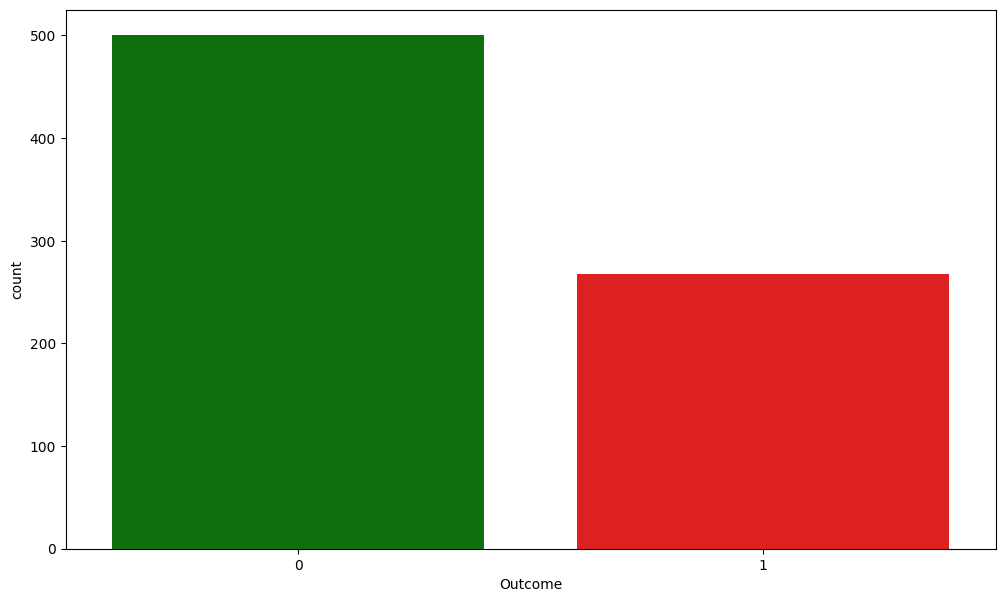

In [13]:
plt.figure(figsize=(12,7))
sns.countplot(
    x="Outcome",
    data=data,
    hue="Outcome",
    palette={1: "red", 0: "green"},
    legend=False
)
plt.show()

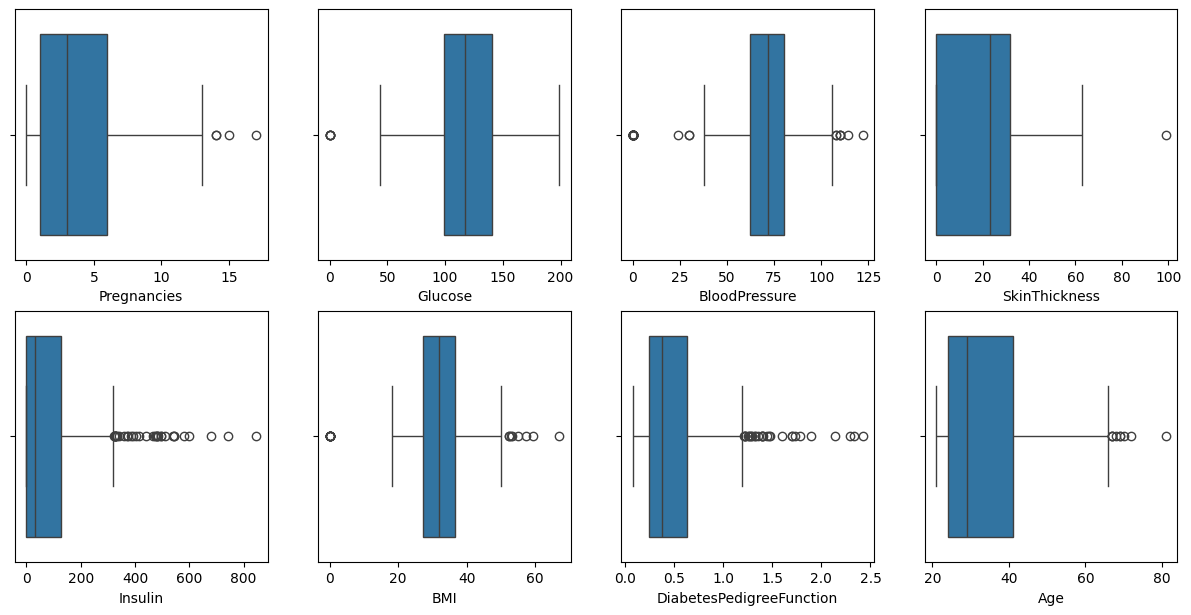

In [17]:
plt.figure(figsize=(15,15))
for i,col in enumerate(["Pregnancies","Glucose","BloodPressure","SkinThickness","Insulin","BMI","DiabetesPedigreeFunction","Age"]):
  plt.subplot(4,4,i+1)
  sns.boxplot(x=col, data=data)
plt.show()

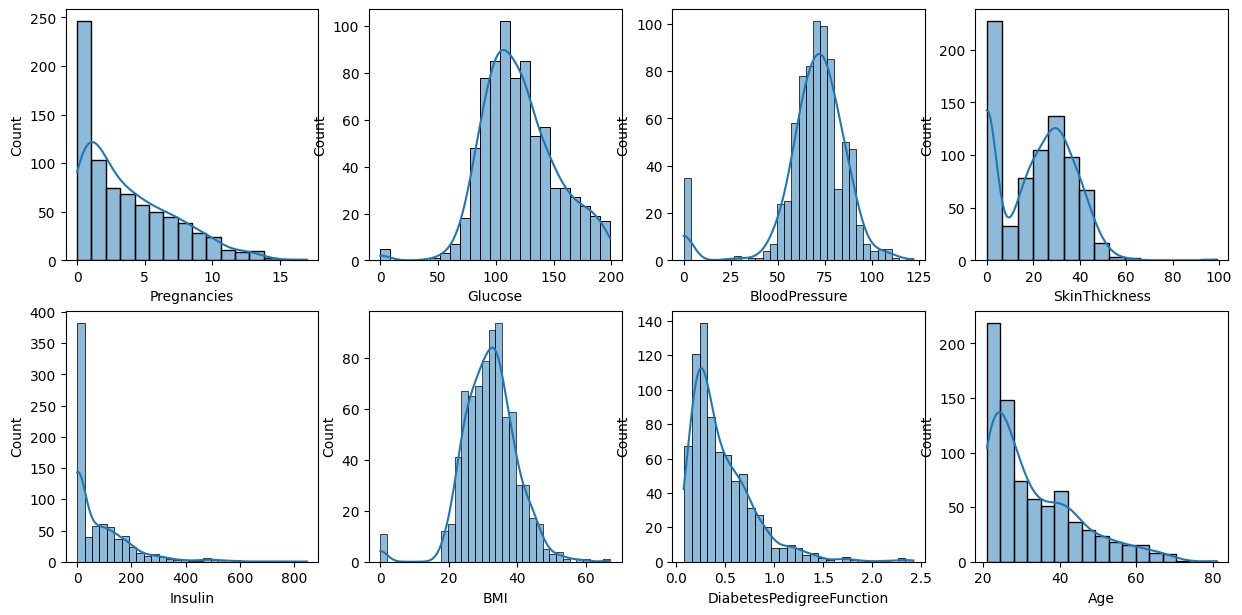

In [18]:
plt.figure(figsize=(15,15))
for i,col in enumerate(["Pregnancies","Glucose","BloodPressure","SkinThickness","Insulin","BMI","DiabetesPedigreeFunction","Age"]):
  plt.subplot(4,4,i+1)
  sns.histplot(x=col, data=data, kde=True)
plt.show()

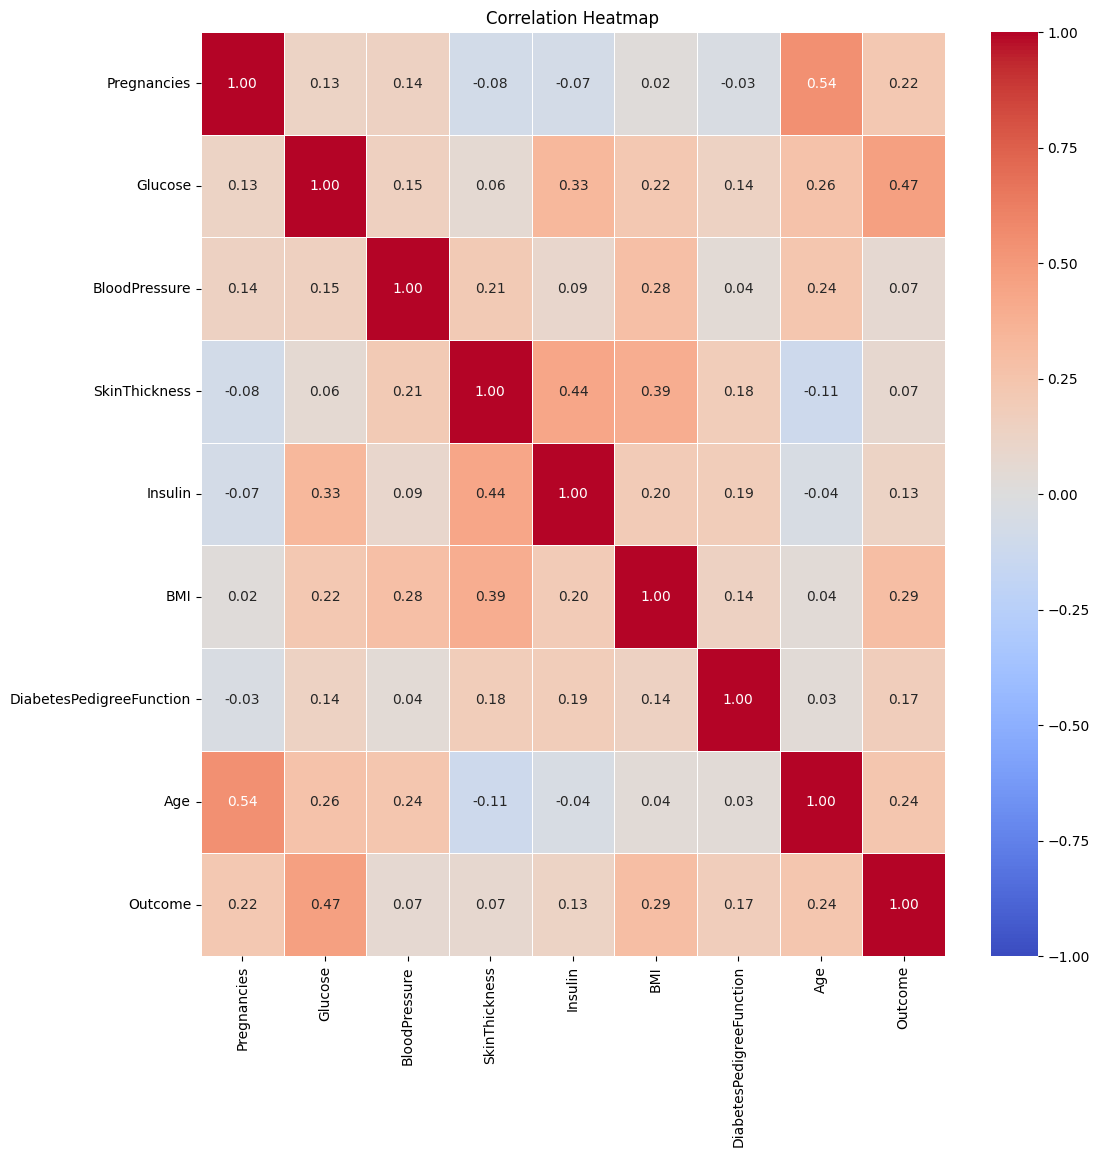

In [20]:

plt.figure(figsize=(12, 12))
sns.heatmap(
    data.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    vmin=-1,
    vmax=1,
    center=0
)
plt.title("Correlation Heatmap")
plt.show()

# **Standard scalling**

In [23]:
from sklearn.preprocessing import StandardScaler
Ss=StandardScaler()
X=pd.DataFrame(Ss.fit_transform(data.drop(["Outcome"],axis=1),),
columns=["Pregnancies","Glucose","BloodPressure","SkinThickness","Insulin","BMI","DiabetesPedigreeFunction","Age"])

In [24]:
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.639947,0.848324,0.149641,0.907270,-0.692891,0.204013,0.468492,1.425995
1,-0.844885,-1.123396,-0.160546,0.530902,-0.692891,-0.684422,-0.365061,-0.190672
2,1.233880,1.943724,-0.263941,-1.288212,-0.692891,-1.103255,0.604397,-0.105584
3,-0.844885,-0.998208,-0.160546,0.154533,0.123302,-0.494043,-0.920763,-1.041549
4,-1.141852,0.504055,-1.504687,0.907270,0.765836,1.409746,5.484909,-0.020496


In [25]:
Y=data["Outcome"]
Y.head()

,Outcome
0,1
1,0
2,1
3,0
4,1


In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split



In [38]:
lr=LogisticRegression()
#for i in range(0,100):
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=16)
lr.fit(x_train,y_train)
train_score = lr.score(x_train,y_train)*100
test_score = lr.score(x_test, y_test)*100
print(f"Training Score: {train_score} Testing Score: {test_score}" )
print("training data shape:",x_train.shape)
print("testing data shape:",x_test.shape)


Training Score: 77.19869706840392 Testing Score: 81.81818181818183
training data shape: (614, 8)
testing data shape: (154, 8)


In [54]:
y_pred_lr=lr.predict(x_test)
accuracy_lr=accuracy_score(y_test,y_pred_lr)
confusion_mx=confusion_matrix(y_test,y_pred_lr)
print("ACCURACY SCORE: ",accuracy_lr*100)
print("CONFUSION MATRIX: ",confusion_mx)

ACCURACY SCORE:  81.81818181818183
CONFUSION MATRIX:  [[95  7]
 [21 31]]


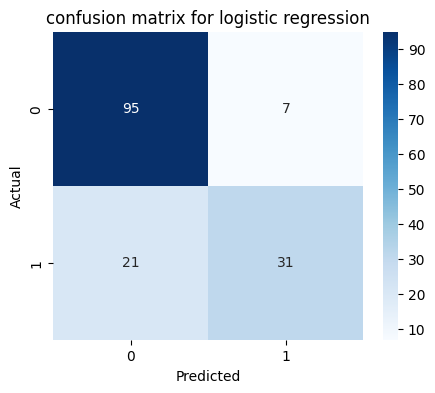

In [42]:
plt.figure(figsize=(5,4))
sns.heatmap(confusion_mx,annot=True ,fmt ='d', cmap="Blues")
plt.title("confusion matrix for logistic regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# **Predict by Using Logistic Regression**

In [50]:
x = np.array([[1,85,66,29,0,26.6,0.351,31]])
predict = lr.predict(x)
print("Prediction:", predict)


Prediction: [1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(



 Random Forest Accuracy: 81.17 %

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.91      0.87       102
           1       0.78      0.62      0.69        52

    accuracy                           0.81       154
   macro avg       0.80      0.76      0.78       154
weighted avg       0.81      0.81      0.81       154



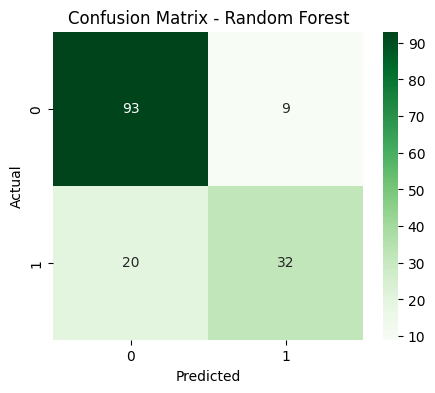

In [51]:
#RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(x_train, y_train)
y_pred_rf = rf_model.predict(x_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
cm_rf = confusion_matrix(y_test, y_pred_rf)

print("\n Random Forest Accuracy:", round(accuracy_rf * 100, 2), "%")
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

# Confusion Matrix Visualization
plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Model Comparison
                    Model  Accuracy
0      LogisticRegression  0.818182
1  RandomForestClassifier  0.811688


/tmp/ipykernel_1086/101729471.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model',y='Accuracy',data=results,palette='coolwarm')


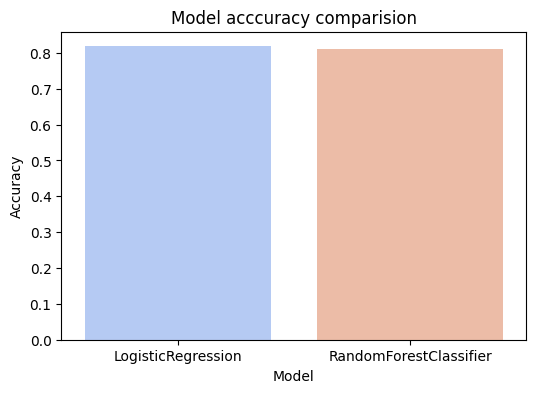

In [55]:
# comparing model
results = pd.DataFrame({
    'Model': ["LogisticRegression", "RandomForestClassifier"],
    'Accuracy': [accuracy_lr, accuracy_rf]
})
print("Model Comparison")
print(results)

plt.figure(figsize=(6,4))
sns.barplot(x='Model',y='Accuracy',data=results,palette='coolwarm')
plt.title("Model acccuracy comparision")
plt.show()